C:\Users\nagar\AppData\Local\Temp\ipykernel_4876\328604589.py:15: DtypeWarning: Columns (0: # This file was produced by the NASA Exoplanet Archive  http://exoplanetarchive.ipac.caltech.edu, 1: Unnamed: 4, 2: Unnamed: 5, 3: Unnamed: 9, 4: Unnamed: 10, 5: Unnamed: 11, 6: Unnamed: 12, 7: Unnamed: 13, 8: Unnamed: 15, 9: Unnamed: 22, 10: Unnamed: 23, 11: Unnamed: 24, 12: Unnamed: 25, 13: Unnamed: 26, 14: Unnamed: 27, 15: Unnamed: 28, 16: Unnamed: 29, 17: Unnamed: 30, 18: Unnamed: 31, 19: Unnamed: 33, 20: Unnamed: 35, 21: Unnamed: 36, 22: Unnamed: 37, 23: Unnamed: 38, 24: Unnamed: 39, 25: Unnamed: 40, 26: Unnamed: 41, 27: Unnamed: 42, 28: Unnamed: 43, 29: Unnamed: 44, 30: Unnamed: 45, 31: Unnamed: 46, 32: Unnamed: 47, 33: Unnamed: 48, 34: Unnamed: 49, 35: Unnamed: 50, 36: Unnamed: 51, 37: Unnamed: 52, 38: Unnamed: 53, 39: Unnamed: 54, 40: Unnamed: 55, 41: Unnamed: 56, 42: Unnamed: 57, 43: Unnamed: 58, 44: Unnamed: 59, 45: Unnamed: 60, 46: Unnamed: 61, 47: Unnamed: 62, 48: Unnamed: 63, 49: Un

Initial Shape: (39610, 289)
After Removing Duplicates: (39608, 289)

Summary Statistics:
       # This file was produced by the NASA Exoplanet Archive  http://exoplanetarchive.ipac.caltech.edu  \
count                                               39608                                                 
unique                                              39608                                                 
top                            # Sat Feb  7 06:09:53 2026                                                 
freq                                                    1                                                 

       Unnamed: 1 Unnamed: 2 Unnamed: 3 Unnamed: 4 Unnamed: 5     Unnamed: 6  \
count       39316      39316      39316       2921       3197          38524   
unique       6101       4552          9        731        774           4284   
top      TrES-2 b  Kepler-11          b   HD 75732  HIP 43587  TIC 169175503   
freq           34        103      28393         61     

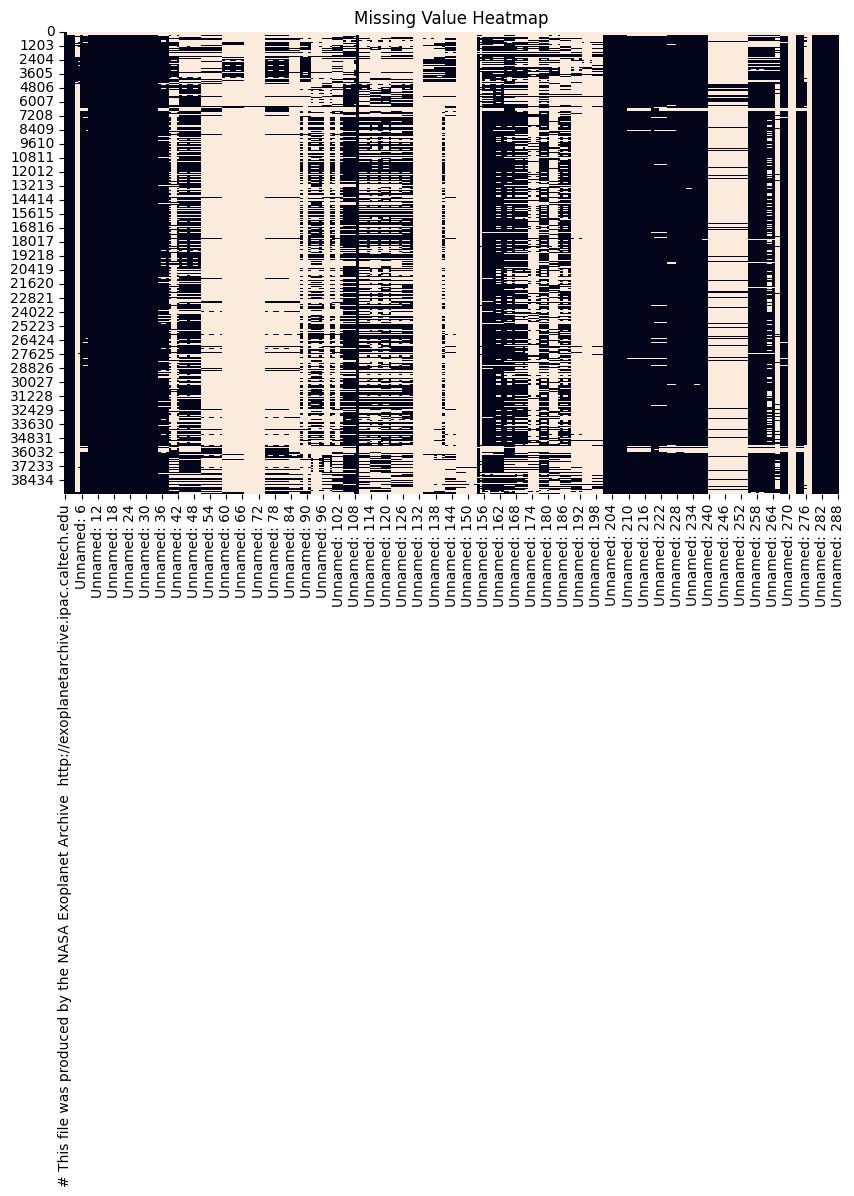

C:\Users\nagar\AppData\Local\Temp\ipykernel_4876\328604589.py:57: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=["object", "category"]).columns.tolist()


After Outlier Removal: (39608, 289)


MemoryError: Unable to allocate 126. MiB for an array with shape (39608, 3337) and data type int8

In [1]:
# ============================================================
# EXOHABITAI - FULL DOCUMENT-COMPLIANT PREPROCESSING PIPELINE
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# -----------------------------
# 1. LOAD DATA
# -----------------------------
df = pd.read_csv("B13-EXOHABITAI.csv")
print("Initial Shape:", df.shape)

# -----------------------------
# 2. REMOVE DUPLICATES
# -----------------------------
df.drop_duplicates(inplace=True)
print("After Removing Duplicates:", df.shape)

# -----------------------------
# 3. REMOVE COMPLETELY NULL ROWS
# -----------------------------
df.dropna(how="all", inplace=True)

# -----------------------------
# 4. REMOVE OBVIOUS ID COLUMNS
# -----------------------------
df.drop(columns=["planet_name", "star_name", "planet_id"],
        errors="ignore", inplace=True)

# -----------------------------
# 5. DATA QUALITY SUMMARY
# -----------------------------
print("\nSummary Statistics:")
print(df.describe(include="all"))

print("\nMissing Values:")
print(df.isnull().sum())

# Optional Heatmap (Safe)
try:
    plt.figure(figsize=(10,6))
    sns.heatmap(df.isnull(), cbar=False)
    plt.title("Missing Value Heatmap")
    plt.show()
except:
    pass

# -----------------------------
# 6. IDENTIFY COLUMN TYPES
# -----------------------------
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(include=["object", "category"]).columns.tolist()

# -----------------------------
# 7. HANDLE MISSING VALUES (DOCUMENT METHOD)
# -----------------------------

# Numeric → Median
for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

# Categorical → Mode
for col in categorical_cols:
    if not df[col].mode().empty:
        df[col] = df[col].fillna(df[col].mode()[0])
    else:
        df[col] = df[col].fillna("Unknown")

# -----------------------------
# 8. REMOVE PHYSICALLY IMPOSSIBLE VALUES
# -----------------------------

# Remove negative radius
if "planet_radius" in df.columns:
    df = df[df["planet_radius"] > 0]

# Remove unrealistic temperatures (< 0 Kelvin)
if "equilibrium_temperature" in df.columns:
    df = df[df["equilibrium_temperature"] > 0]

# -----------------------------
# 9. OUTLIER DETECTION (IQR METHOD)
# -----------------------------
for col in numeric_cols:
    if col in df.columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        df = df[(df[col] >= lower) & (df[col] <= upper)]

print("After Outlier Removal:", df.shape)

# -----------------------------
# 10. UNIT STANDARDIZATION (SAFE CHECKS)
# -----------------------------
# NOTE: Only converts if obvious unit issues detected

# Example: If radius looks too large (>100), assume km → convert to Earth radii
if "planet_radius" in df.columns:
    if df["planet_radius"].mean() > 100:
        df["planet_radius"] = df["planet_radius"] / 6371  # km to Earth radius approx

# Example: Temperature in Celsius → convert to Kelvin
if "equilibrium_temperature" in df.columns:
    if df["equilibrium_temperature"].mean() < 200:
        df["equilibrium_temperature"] += 273.15

# -----------------------------
# 11. FEATURE ENGINEERING
# -----------------------------

# -------- Habitability Score Index --------
required_habit = [
    "equilibrium_temperature",
    "planet_radius",
    "semi_major_axis",
    "star_luminosity"
]

if all(col in df.columns for col in required_habit):

    temp_score = (1 - abs(df["equilibrium_temperature"] - 288) / 288).clip(0,1)
    radius_score = (1 - abs(df["planet_radius"] - 1)).clip(0,1)
    orbit_score = (1 - abs(df["semi_major_axis"] - 1)).clip(0,1)
    luminosity_score = df["star_luminosity"].clip(0,2) / 2

    df["habitability_score"] = (
        temp_score + radius_score + orbit_score + luminosity_score
    ) / 4

# -------- Stellar Compatibility Index --------
stellar_cols = ["star_temperature", "star_luminosity"]

if all(col in df.columns for col in stellar_cols):

    star_temp_score = (1 - abs(df["star_temperature"] - 5778) / 5778).clip(0,1)
    star_lum_score = df["star_luminosity"].clip(0,2) / 2

    df["stellar_compatibility_index"] = (
        star_temp_score + star_lum_score
    ) / 2

# -------- Orbital Stability Factor --------
orbital_cols = ["orbital_period", "semi_major_axis"]

if all(col in df.columns for col in orbital_cols):

    period_score = (1 - abs(df["orbital_period"] - 365) / 365).clip(0,1)
    orbit_score = (1 - abs(df["semi_major_axis"] - 1)).clip(0,1)

    df["orbital_stability_factor"] = (
        period_score + orbit_score
    ) / 2

# -----------------------------
# 12. TARGET VARIABLE CREATION
# -----------------------------
if "habitability_score" in df.columns:
    df["habitable_class"] = np.where(
        df["habitability_score"] > df["habitability_score"].median(),
        1, 0
    )

# -----------------------------
# 13. CATEGORICAL ENCODING
# -----------------------------
if len(categorical_cols) > 0:
    df = pd.get_dummies(
        df,
        columns=categorical_cols,
        drop_first=True,
        dtype="int8"
    )

print("After Encoding:", df.shape)

# -----------------------------
# 14. FEATURE SCALING
# -----------------------------
numeric_cols_updated = df.select_dtypes(include=[np.number]).columns.tolist()

if "habitable_class" in numeric_cols_updated:
    numeric_cols_updated.remove("habitable_class")

scaler = StandardScaler()
df[numeric_cols_updated] = scaler.fit_transform(df[numeric_cols_updated])

# -----------------------------
# 15. TRAIN-TEST SPLIT
# -----------------------------
if "habitable_class" in df.columns:
    X = df.drop("habitable_class", axis=1)
    y = df["habitable_class"]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.2,
        random_state=42
    )

    print("Train Shape:", X_train.shape)
    print("Test Shape:", X_test.shape)

# -----------------------------
# 16. SAVE FINAL DATASET
# -----------------------------
df.to_csv("preprocessed.csv", index=False)

print("\n✅ FULL PREPROCESSING COMPLETED SUCCESSFULLY")
